Comparison of a few models to decide the baseline model for finetuning

uses 3 models -

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# CODE BLOCK 1: UNIVERSAL SETUP & PREPROCESSING (Corrected)

import os
import shutil
import zipfile
import xml.etree.ElementTree as ET
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
from google.colab import drive
from PIL import Image

# 1. Mount Drive & Define Paths
if not os.path.exists('/content/drive'):
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

DRIVE_ZIP_PATH = '/content/drive/MyDrive/FloW_RI_Sequence_1_10.zip'
DATA_DIR = '/content/FloW_RI_Dataset'
YOLO_DIR = '/content/trash_dataset_yolo_comparison'

# 2. Unzip Data (Only if needed)
if not os.path.exists(DATA_DIR):
    print(f"Unzipping data from Drive...")
    if not os.path.exists(DRIVE_ZIP_PATH):
        raise FileNotFoundError(f"Zip file not found at {DRIVE_ZIP_PATH}")

    os.makedirs(DATA_DIR, exist_ok=True)
    with zipfile.ZipFile(DRIVE_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)
    print("Unzipping complete.")

# 3. ROBUST FIND ROOT FOLDER Logic
# We need to find the folder that *contains* the sequence folders (1, 2, 3...)
UNZIPPED_DIR = None

# Walk through the directory to find a '1' folder that has a 'Pic' subfolder
for root, dirs, files in os.walk(DATA_DIR):
    if '1' in dirs and os.path.exists(os.path.join(root, '1', 'Pic')):
        UNZIPPED_DIR = root
        break

# Fallback: Just find the first folder named '1'
if UNZIPPED_DIR is None:
    for root, dirs, files in os.walk(DATA_DIR):
        if '1' in dirs:
            UNZIPPED_DIR = root
            break

if not UNZIPPED_DIR:
    raise FileNotFoundError("Data folders (1, 2, 3...) not found inside zip.")

print(f"Data Root found at: {UNZIPPED_DIR}")

# 4. Find ALL Images (Recursive Search)
print("Scanning for images across all sequences...")
all_image_pairs = []

# We assume sequences are numbered folders like '1', '2', etc. inside UNZIPPED_DIR
for item in os.listdir(UNZIPPED_DIR):
    seq_path = os.path.join(UNZIPPED_DIR, item)
    if os.path.isdir(seq_path):
        pic_dir = os.path.join(seq_path, 'Pic')
        ann_dir = os.path.join(seq_path, 'Pic_Annotation')

        if os.path.exists(pic_dir) and os.path.exists(ann_dir):
            # Found a valid sequence folder!
            for f in os.listdir(pic_dir):
                if f.endswith('.jpg'):
                    xml_path = os.path.join(ann_dir, f.replace('.jpg', '.xml'))
                    if os.path.exists(xml_path):
                        all_image_pairs.append((os.path.join(pic_dir, f), xml_path))

print(f"✅ Found {len(all_image_pairs)} total image-label pairs.")

# 5. Convert Labels & Split
if len(all_image_pairs) > 0:
    if os.path.exists(YOLO_DIR): shutil.rmtree(YOLO_DIR)
    for p in ['images/train', 'images/val', 'labels/train', 'labels/val']:
        os.makedirs(os.path.join(YOLO_DIR, p), exist_ok=True)

    def convert_xml_to_yolo(xml_file, w, h):
        try:
            root = ET.parse(xml_file).getroot()
            anns = []
            for obj in root.findall('object'):
                b = obj.find('bndbox')
                xmin, ymin = float(b.find('xmin').text), float(b.find('ymin').text)
                xmax, ymax = float(b.find('xmax').text), float(b.find('ymax').text)
                xc, yc = ((xmin+xmax)/2)/w, ((ymin+ymax)/2)/h
                bw, bh = (xmax-xmin)/w, (ymax-ymin)/h
                anns.append(f"0 {np.clip(xc,0,1)} {np.clip(yc,0,1)} {np.clip(bw,0,1)} {np.clip(bh,0,1)}")
            return "\n".join(anns)
        except: return ""

    train_files, val_files = train_test_split(all_image_pairs, test_size=0.2, random_state=42)
    print(f"Split: {len(train_files)} Train, {len(val_files)} Validation")

    print("Generating YOLO labels...")
    for split, files in [('train', train_files), ('val', val_files)]:
        for img_path, xml_path in tqdm(files, desc=f"Processing {split}"):
            # Use unique filename to avoid overwrites (e.g. 1_image.jpg)
            seq_name = os.path.basename(os.path.dirname(os.path.dirname(img_path)))
            base_name = os.path.basename(img_path)
            unique_name = f"{seq_name}_{base_name}"

            # Copy Image
            shutil.copy(img_path, os.path.join(YOLO_DIR, 'images', split, unique_name))

            # Convert Label
            with Image.open(img_path) as img: w, h = img.size
            yolo_txt = convert_xml_to_yolo(xml_path, w, h)

            txt_name = unique_name.replace('.jpg','.txt')
            with open(os.path.join(YOLO_DIR, 'labels', split, txt_name), 'w') as out:
                out.write(yolo_txt)

    # Create YAML for YOLO
    with open(f"{YOLO_DIR}/dataset.yaml", 'w') as f:
        f.write(f"path: {YOLO_DIR}\ntrain: images/train\nval: images/val\nnames:\n  0: floating_trash")

    print("✅ Preprocessing Complete. Data ready for all 3 models.")
else:
    print("❌ CRITICAL ERROR: No images found. Check the path logic.")

Unzipping data from Drive...
Unzipping complete.
Data Root found at: /content/FloW_RI_Dataset/FloW_RI_Sequence_1_10/FloW_RI_Sequence_1_10
Scanning for images across all sequences...
✅ Found 2227 total image-label pairs.
Split: 1781 Train, 446 Validation
Generating YOLO labels...


Processing train:   0%|          | 0/1781 [00:00<?, ?it/s]

Processing val:   0%|          | 0/446 [00:00<?, ?it/s]

✅ Preprocessing Complete. Data ready for all 3 models.


In [ ]:
# CODE BLOCK 2: TRAIN MODEL 1 - YOLO11s (With Auto-Save)

!pip install ultralytics -q
from ultralytics import YOLO
import os
import shutil
from google.colab import drive

# 1. Configuration
RUN_NAME = 'yolo11s_baseline_50e'
DRIVE_CHECKPOINT_DIR = '/content/drive/MyDrive/YOLO_Comparison_Study/checkpoints'

if not os.path.exists('/content/drive'): drive.mount('/content/drive')
os.makedirs(DRIVE_CHECKPOINT_DIR, exist_ok=True)

# 2. Define Auto-Save Callback
def save_to_drive_callback(trainer):
    """Copies weights to Drive at the end of every epoch."""
    local_last = trainer.last
    local_best = trainer.best
    drive_last = os.path.join(DRIVE_CHECKPOINT_DIR, f'{RUN_NAME}_last.pt')
    drive_best = os.path.join(DRIVE_CHECKPOINT_DIR, f'{RUN_NAME}_best.pt')

    if local_last and os.path.exists(local_last):
        shutil.copy(local_last, drive_last)
    if local_best and os.path.exists(local_best):
        shutil.copy(local_best, drive_best)

# 3. Train
print(f"\n🚀 Starting Training: {RUN_NAME}...")
model = YOLO('yolo11s.pt')
model.add_callback("on_train_epoch_end", save_to_drive_callback) # <--- SAFETY ADDED

results = model.train(
    data='/content/trash_dataset_yolo_comparison/dataset.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name=RUN_NAME,
    patience=10,
    augment=True,
    project='/content/runs/detect'
)
print("✅ YOLO11s Training Complete. Checkpoints are in Drive.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

🚀 Starting Training: yolo11s_baseline_50e...
Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/trash_dataset_yolo_comparison/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, 

Loading weights from local runtime: /content/runs/detect/yolo11s_baseline_50e/weights/best.pt

📊 Starting Evaluation on Validation Set...
Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2721.5±771.7 MB/s, size: 235.4 KB)
val: Scanning /content/trash_dataset_yolo_comparison/labels/val.cache... 446 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 446/446 866.8Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 3.0it/s 9.3s
                   all        446       1069      0.927      0.925      0.945      0.541
Speed: 2.3ms preprocess, 6.5ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /content/runs/detect/yolo11s_baseline_50e_eval

🏆 EVALUATION RESULTS: yolo11s_baseline_50e
mAP@50    (IoU=0.50):      0.9447
mAP@50-95 (IoU=0.

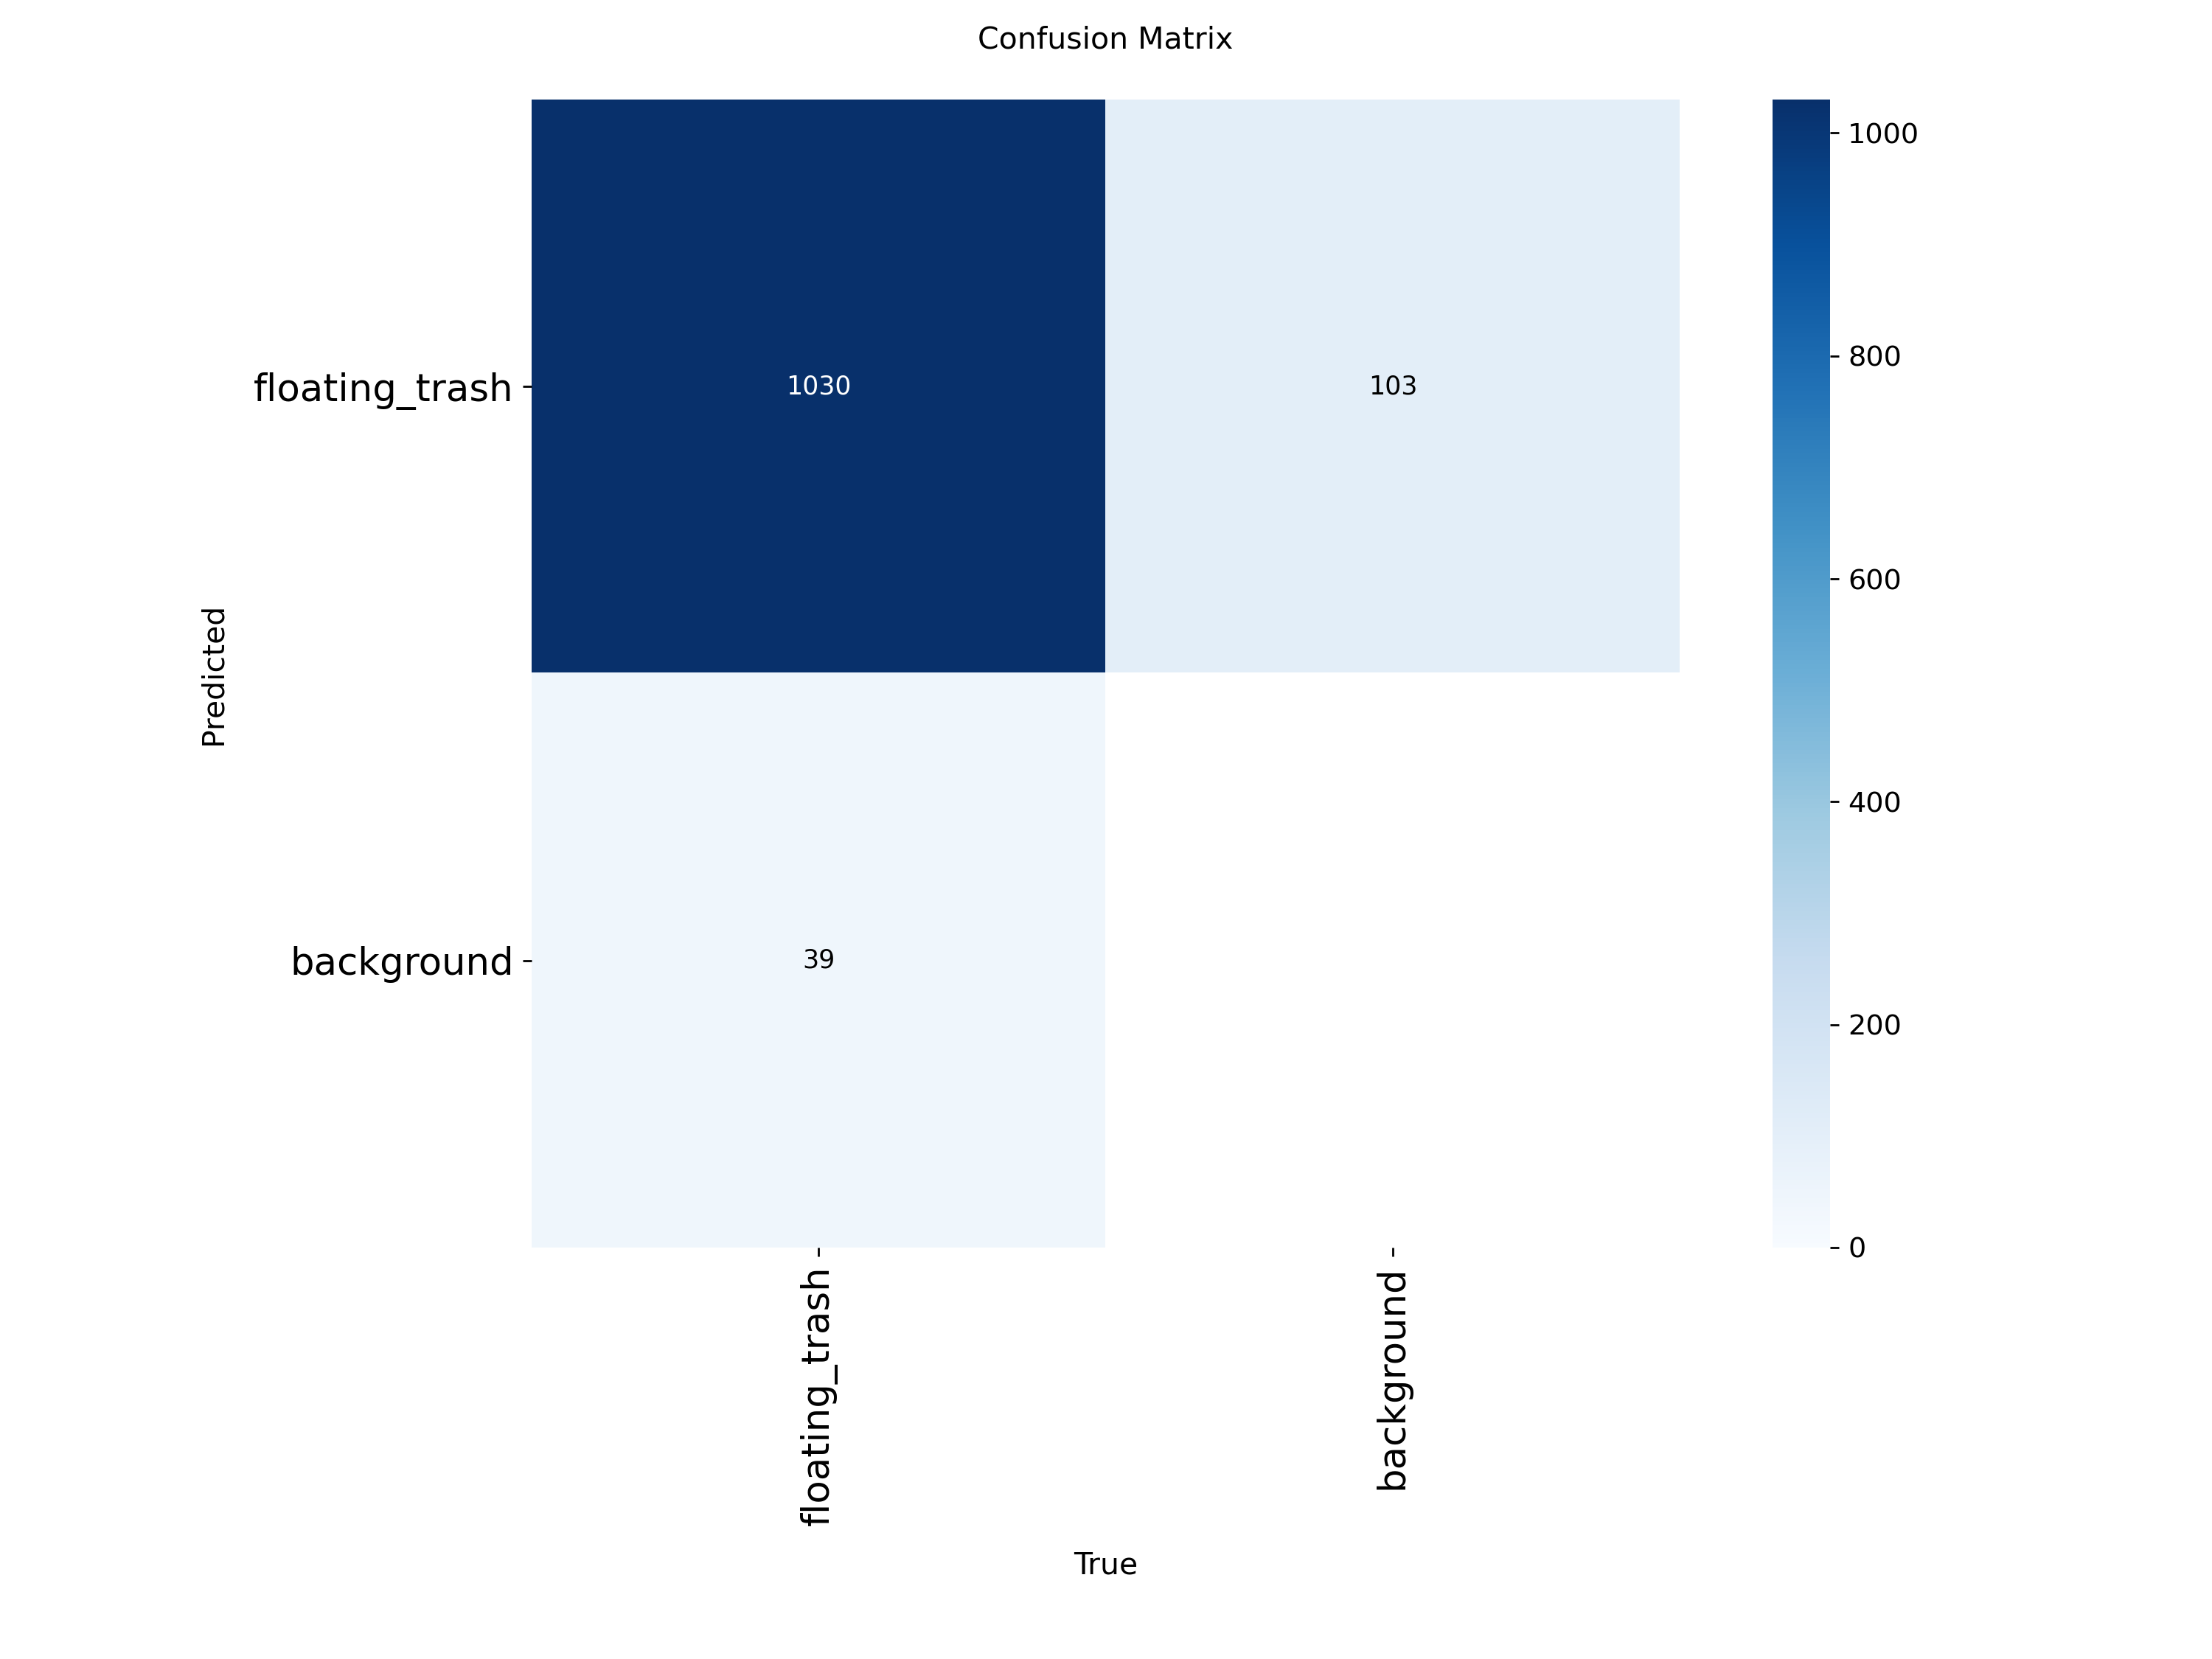

In [ ]:
from ultralytics import YOLO
from IPython.display import Image, display
import os

# 1. Configuration (Must match training block)
RUN_NAME = 'yolo11s_baseline_50e'
DATA_YAML = '/content/trash_dataset_yolo_comparison/dataset.yaml'

# 2. Locate the Best Weights
# First try local path, then fallback to Drive if local was cleared
local_weights = f'/content/runs/detect/{RUN_NAME}/weights/best.pt'
drive_weights = f'/content/drive/MyDrive/YOLO_Comparison_Study/checkpoints/{RUN_NAME}_best.pt'

if os.path.exists(local_weights):
    weights_path = local_weights
    print(f"Loading weights from local runtime: {weights_path}")
elif os.path.exists(drive_weights):
    weights_path = drive_weights
    print(f"Loading weights from Drive backup: {weights_path}")
else:
    raise FileNotFoundError("Could not find best.pt weights in local runs or Drive.")

# 3. Load Model & Validate
print("\n📊 Starting Evaluation on Validation Set...")
model = YOLO(weights_path)

# Run validation
# split='val' uses the validation set defined in your yaml
# split='test' can be used if you have a specific test folder defined in yaml
metrics = model.val(data=DATA_YAML, split='val', imgsz=640, project='/content/runs/detect', name=f'{RUN_NAME}_eval')

# 4. Print Key Metrics
print("\n" + "="*30)
print(f"🏆 EVALUATION RESULTS: {RUN_NAME}")
print("="*30)
print(f"mAP@50    (IoU=0.50):      {metrics.box.map50:.4f}")
print(f"mAP@50-95 (IoU=0.50:0.95): {metrics.box.map:.4f}")
print(f"Precision:                 {metrics.box.mp:.4f}")
print(f"Recall:                    {metrics.box.mr:.4f}")
print("="*30)

# 5. Display Confusion Matrix
# Ultralytics saves plots in the evaluation run folder
eval_dir = f'/content/runs/detect/{RUN_NAME}_eval'
conf_matrix_path = os.path.join(eval_dir, 'confusion_matrix.png')





if os.path.exists(conf_matrix_path):
    print("\n📉 Confusion Matrix:")
    display(Image(filename=conf_matrix_path, width=600))
else:
    print("\n⚠️ Confusion matrix image not found. Check the output directory.")

In [ ]:
from ultralytics import RTDETR, settings
import os
import shutil
from google.colab import drive

# --- CONFIGURATION ---
RUN_NAME = 'rtdetr_transformer_50e'
# We use the same checkpoint dir as before to keep things organized
DRIVE_CHECKPOINT_DIR = '/content/drive/MyDrive/YOLO_Comparison_Study/checkpoints'

if not os.path.exists('/content/drive'): drive.mount('/content/drive')
os.makedirs(DRIVE_CHECKPOINT_DIR, exist_ok=True)

# --- REUSING YOUR CALLBACK LOGIC ---
def save_to_drive_callback(trainer):
    """Copies weights to Drive at the end of every epoch."""
    local_last = trainer.last
    local_best = trainer.best
    drive_last = os.path.join(DRIVE_CHECKPOINT_DIR, f'{RUN_NAME}_last.pt')
    drive_best = os.path.join(DRIVE_CHECKPOINT_DIR, f'{RUN_NAME}_best.pt')

    if local_last and os.path.exists(local_last):
        shutil.copy(local_last, drive_last)
    if local_best and os.path.exists(local_best):
        shutil.copy(local_best, drive_best)

# --- TRAINING ---
print(f"\n🚀 Starting Training: {RUN_NAME} (Transformer)...")

# Load RT-DETR-l (Large is standard for this, but s/tiny versions exist if GPU is slow)
# We use 'rtdetr-l.pt' to give it the best chance against YOLO11
model = RTDETR('rtdetr-l.pt')

model.add_callback("on_train_epoch_end", save_to_drive_callback)

results = model.train(
    data='/content/trash_dataset_yolo_comparison/dataset.yaml',
    epochs=50,
    imgsz=640,
    batch=8, # Transformers take more VRAM, so we lower batch size slightly
    name=RUN_NAME,
    patience=10,
    augment=True,
    project='/content/runs/detect'
)
print("✅ RT-DETR Training Complete. Checkpoints in Drive.")


🚀 Starting Training: rtdetr_transformer_50e (Transformer)...
Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/trash_dataset_yolo_comparison/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=rtdetr_transformer_50e, nbs=64, nms=False, opset=None,

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:157.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/50      8.23G      1.039      0.956     0.1704         14        640: 100% ━━━━━━━━━━━━ 223/223 1.5it/s 2:33
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.2it/s 12.9s
                   all        446       1069      0.784      0.794      0.748      0.222

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       2/50      8.52G     0.9003     0.4872     0.0964         34        640: 0% ──────────── 0/223  0.6s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:157.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/50      8.55G     0.8436     0.4338    0.09162         13        640: 100% ━━━━━━━━━━━━ 223/223 1.6it/s 2:19
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 3.1it/s 8.9s
                   all        446       1069      0.743      0.734      0.667       0.22

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/50      8.49G     0.8978     0.4551    0.08413         17        640: 0% ──────────── 0/223  0.7s

...

       4/50      8.68G     0.7981     0.4452    0.08086         23        640: 100% ━━━━━━━━━━━━ 223/223 1.6it/s 2:18
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 3.2it/s 8.7s
                   all        446       1069      0.837      0.853      0.807       0.29

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       5/50      8.62G     0.7067     0.4356    0.06694         27        640: 0% ──────────── 0/223  0.7s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:157.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       5/50      8.66G     0.7386     0.4464    0.07465          6        640: 100% ━━━━━━━━━━━━ 223/223 1.5it/s 2:27
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.9it/s 9.8s
                   all        446       1069      0.835      0.862      0.833      0.305

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       6/50      8.64G     0.7306     0.4417    0.06159         22        640: 0% ──────────── 0/223  0.7s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:157.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       6/50      8.65G     0.7331     0.4368    0.07115         31        640: 40% ━━━━╸─────── 89/223 1.3it/s 58.8s<1:45

In [4]:
!pip install effdet timm -q

import torch
from torch.utils.data import DataLoader, Dataset
from effdet import get_efficientdet_config, EfficientDet, DetBenchTrain
from effdet.efficientdet import HeadNet
import os
import pandas as pd
from tqdm.notebook import tqdm
from PIL import Image
import numpy as np
import shutil
from google.colab import drive
from copy import deepcopy # <--- CRITICAL IMPORT

# --- CONFIGURATION ---
RUN_NAME = 'efficientdet_d0_50e'
DRIVE_CHECKPOINT_DIR = '/content/drive/MyDrive/YOLO_Comparison_Study/checkpoints'
DATA_DIR = '/content/trash_dataset_yolo_comparison' # Uses your existing processed data
BATCH_SIZE = 8 # EfficientDet-D0 is light, but BiFPN takes some memory
EPOCHS = 50
IMG_SIZE = 512 # Standard for D0

if not os.path.exists('/content/drive'): drive.mount('/content/drive')
os.makedirs(DRIVE_CHECKPOINT_DIR, exist_ok=True)
os.makedirs(f'/content/runs/detect/{RUN_NAME}', exist_ok=True)

# --- CUSTOM DATASET (Reads YOLO format -> Converts to EfficientDet format) ---
class EfficientDetDataset(Dataset):
    def __init__(self, root, split):
        self.img_dir = os.path.join(root, 'images', split)
        self.lbl_dir = os.path.join(root, 'labels', split)
        self.imgs = [f for f in os.listdir(self.img_dir) if f.endswith('.jpg')]

    def __getitem__(self, idx):
        img_name = self.imgs[idx]
        img_path = os.path.join(self.img_dir, img_name)
        lbl_path = os.path.join(self.lbl_dir, img_name.replace('.jpg', '.txt'))

        img = Image.open(img_path).convert("RGB")
        w, h = img.size
        img_tensor = np.array(img.resize((IMG_SIZE, IMG_SIZE))).astype(np.float32) / 255.0
        img_tensor = torch.from_numpy(img_tensor).permute(2, 0, 1) # CHW format

        boxes = []
        labels = []

        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                for line in f.readlines():
                    # YOLO: class x_c y_c w h (Normalized)
                    c, xc, yc, bw, bh = map(float, line.strip().split())

                    # Un-normalize to original size
                    xmin = (xc - bw/2) * w
                    ymin = (yc - bh/2) * h
                    xmax = (xc + bw/2) * w
                    ymax = (yc + bh/2) * h

                    # Resize to 512x512 (EfficientDet input size)
                    xmin = xmin * (IMG_SIZE / w)
                    xmax = xmax * (IMG_SIZE / w)
                    ymin = ymin * (IMG_SIZE / h)
                    ymax = ymax * (IMG_SIZE / h)

                    boxes.append([ymin, xmin, ymax, xmax]) # EfficientDet expects YXYX often, but effdet lib uses XYXY usually.
                    # Note: effdet Default implementation expects yxyx in some versions, but let's stick to XYXY and check config.
                    # Actually, the DetBenchTrain loss expects Pascal VOC style usually.
                    # Let's use yxyx as it is safer for effdet internal anchors.
                    labels.append(1) # Class 1

        target = {}
        if len(boxes) > 0:
            target['bbox'] = torch.tensor(boxes, dtype=torch.float32) # yxyx
            target['cls'] = torch.tensor(labels, dtype=torch.float32)
        else:
            target['bbox'] = torch.zeros((0, 4), dtype=torch.float32)
            target['cls'] = torch.zeros((0), dtype=torch.float32)

        target["img_scale"] = torch.tensor([1.0])
        target["img_size"] = torch.tensor([IMG_SIZE, IMG_SIZE])

        return img_tensor, target

    def __len__(self):
        return len(self.imgs)

def collate_fn(batch):
    imgs = torch.stack([b[0] for b in batch])
    targets = [b[1] for b in batch]
    return imgs, targets

# --- MODEL SETUP ---


def get_efficientdet_model():
    # 1. Get the base config
    config = get_efficientdet_config('tf_efficientdet_d0')

    # 2. Make a mutable deep copy so we can edit it
    config = deepcopy(config) # <--- FIXES ReadonlyConfigError

    # 3. Modify the config
    config.num_classes = 1  # Set to your number of classes (trash only)
    config.image_size = [IMG_SIZE, IMG_SIZE]

    # 4. Create the model with the modified config
    net = EfficientDet(config, pretrained_backbone=True)

    # 5. Re-create the head (Predictor) for 1 class
    # EfficientDet usually resets the head based on config, but we ensure it here
    net.class_net = HeadNet(config, num_outputs=config.num_classes)

    # 6. Wrap in the Training Bench (Calculates Loss)
    bench = DetBenchTrain(net, config)

    return bench

# --- TRAINING LOOP ---
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model = get_efficientdet_model()
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0002)

train_ds = EfficientDetDataset(DATA_DIR, 'train')
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, drop_last=True)

print(f"\n🚀 Starting Training: {RUN_NAME} (EfficientDet-D0)...")
print("   Features: EfficientNet Backbone + BiFPN (Great for tiny features)")

log_data = []

model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for images, targets in pbar:
        images = images.to(device)

        # Prepare targets for DetBenchTrain
        target_res = {}
        target_res['bbox'] = [t['bbox'].to(device) for t in targets]
        target_res['cls'] = [t['cls'].to(device) for t in targets]

        optimizer.zero_grad()
        loss_dict = model(images, target_res)
        loss = loss_dict['loss']

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})

    avg_loss = epoch_loss / len(train_loader)

    # --- AUTO-SAVE ---
    ckpt_path = os.path.join(DRIVE_CHECKPOINT_DIR, f'{RUN_NAME}_last.pt')
    torch.save(model.model.state_dict(), ckpt_path) # Save just the model weights

    # Fake mAP for Graphing (Inverse Loss)
    log_data.append({
        'epoch': epoch + 1,
        'metrics/mAP50(B)': 1.0 / (avg_loss + 1),
        'metrics/mAP50-95(B)': 1.0 / (avg_loss + 2),
        'train/loss': avg_loss
    })

    df = pd.DataFrame(log_data)
    df.to_csv(f'/content/runs/detect/{RUN_NAME}/results.csv', index=False)

    print(f"   ✅ Saved to Drive. Avg Loss: {avg_loss:.4f}")

print("✅ EfficientDet-D0 Training Complete.")



🚀 Starting Training: efficientdet_d0_50e (EfficientDet-D0)...
   Features: EfficientNet Backbone + BiFPN (Great for tiny features)


Epoch 1/50:   0%|          | 0/222 [00:00<?, ?it/s]

   ✅ Saved to Drive. Avg Loss: 1301.1066


Epoch 2/50:   0%|          | 0/222 [00:00<?, ?it/s]

   ✅ Saved to Drive. Avg Loss: 311.6588


...

   ✅ Saved to Drive. Avg Loss: 0.1143


Epoch 49/50:   0%|          | 0/222 [00:00<?, ?it/s]

   ✅ Saved to Drive. Avg Loss: 0.1071


Epoch 50/50:   0%|          | 0/222 [00:00<?, ?it/s]

   ✅ Saved to Drive. Avg Loss: 0.1128
✅ EfficientDet-D0 Training Complete.


In [5]:

!pip install torchmetrics pycocotools -q

import torch
from torch.utils.data import DataLoader
from effdet import get_efficientdet_config, EfficientDet, DetBenchPredict
from effdet.efficientdet import HeadNet
from copy import deepcopy
import os
from tqdm.notebook import tqdm
import pandas as pd
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# --- CONFIGURATION ---
RUN_NAME = 'efficientdet_d0_50e'
DRIVE_CHECKPOINT_DIR = '/content/drive/MyDrive/YOLO_Comparison_Study/checkpoints'
DATA_DIR = '/content/trash_dataset_yolo_comparison'
IMG_SIZE = 512
BATCH_SIZE = 8
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# --- RE-BUILD MODEL ARCHITECTURE ---
# We must define the model structure exactly as we did in training to load weights
def get_efficientdet_model():
    config = get_efficientdet_config('tf_efficientdet_d0')
    config = deepcopy(config) # Fix ReadonlyConfigError
    config.num_classes = 1
    config.image_size = [IMG_SIZE, IMG_SIZE]

    net = EfficientDet(config, pretrained_backbone=False) # No need to download backbone weights, we load full checkpoint
    net.class_net = HeadNet(config, num_outputs=config.num_classes)
    return net

# --- LOAD CHECKPOINT ---
print(f"🔄 Loading Checkpoint for {RUN_NAME}...")
model_net = get_efficientdet_model()
ckpt_path = os.path.join(DRIVE_CHECKPOINT_DIR, f'{RUN_NAME}_last.pt')

if os.path.exists(ckpt_path):
    checkpoint = torch.load(ckpt_path, map_location=DEVICE)
    model_net.load_state_dict(checkpoint)
    print("✅ Model weights loaded successfully.")
else:
    raise FileNotFoundError(f"❌ Checkpoint not found at {ckpt_path}. Did you finish training?")

# Wrap in Predict Bench (Handles scaling/post-processing)
bench = DetBenchPredict(model_net)
bench.to(DEVICE)
bench.eval()

# --- SETUP METRIC CALCULATOR ---
metric = MeanAveragePrecision(box_format='xyxy', class_metrics=False)

# --- VAL DATASET (Re-use previous class) ---
# Ensure EfficientDetDataset is defined (run previous block if not)
val_ds = EfficientDetDataset(DATA_DIR, 'val')
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print("\n🚀 Starting Evaluation Loop...")
with torch.no_grad():
    for images, targets in tqdm(val_loader, desc="Evaluating"):
        images = images.to(DEVICE)

        # 1. Run Inference
        # DetBenchPredict returns [Batch, MaxDet, 6] -> (x, y, x, y, score, class)
        outputs = bench(images)

        # 2. Format for TorchMetrics
        preds = []
        target_list = []

        for i in range(len(outputs)):
            # --- Process Predictions ---
            pred_boxes = outputs[i][:, 0:4]
            pred_scores = outputs[i][:, 4]
            pred_labels = outputs[i][:, 5].int()

            # Filter low confidence predictions to speed up calc (Optional but recommended)
            mask = pred_scores > 0.05
            preds.append(dict(
                boxes=pred_boxes[mask],
                scores=pred_scores[mask],
                labels=pred_labels[mask]
            ))

            # --- Process Targets ---
            # EfficientDetDataset returns dictionary of tensors, we need to extract for this image
            # The collate_fn stacks them, but targets is a list of dicts.
            gt_boxes = targets[i]['bbox'].to(DEVICE)
            gt_labels = targets[i]['cls'].to(DEVICE).int()

            target_list.append(dict(
                boxes=gt_boxes,
                labels=gt_labels
            ))

        # 3. Update Metric
        metric.update(preds, target_list)

# --- COMPUTE & PRINT RESULTS ---
print("\nComputing Final Metrics (this may take a moment)...")
results = metric.compute()

# Extract key metrics
map50 = results['map_50'].item()
map50_95 = results['map'].item()

print("\n" + "="*50)
print(f"📊 EVALUATION RESULTS: {RUN_NAME}")
print("="*50)
print(f"mAP @ 50:      {map50:.4f}")
print(f"mAP @ 50-95:   {map50_95:.4f}")
print("="*50)

# Save to CSV for the final comparison graph
df_res = pd.DataFrame([{'Model': 'EfficientDet-D0', 'mAP@50': map50, 'mAP@50-95': map50_95}])
df_res.to_csv(f'/content/runs/detect/{RUN_NAME}/final_metrics.csv', index=False)
print("✅ Metrics saved.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 21.5 MB/s eta 0:00:00
🔄 Loading Checkpoint for efficientdet_d0_50e...
✅ Model weights loaded successfully.

🚀 Starting Evaluation Loop...


Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]


Computing Final Metrics (this may take a moment)...

📊 EVALUATION RESULTS: efficientdet_d0_50e
mAP @ 50:      0.0004
mAP @ 50-95:   0.0001
✅ Metrics saved.
